Imports

In [ ]:
# !pip install tensorflow

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sn
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


load and preprocess the data

In [ ]:
# used paths
working_dir = '/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation'
data_path = os.path.join(working_dir, 'data')
models_path =  os.path.join(working_dir, 'models')
visualisations_path = os.path.join(working_dir, 'visualizations')
selected_path = data_path+'/selected_scada'

In [ ]:
# knowledge based feature selected scada datasets
scada_60_postfailure = selected_path+'/KwSelection_scada_post_failure_60.csv'
# scada_60_Knw_selected = selected_path+'/knowledge_selected_scada_60.csv'

# scada_30 = os.path.join(data_path,'scada_labeled_merged_30days.csv')
# scada_60= os.path.join(data_path,'scada_labeled_merged_60days.csv')

In [ ]:
# scada_30 = pd.read_csv(scada_30_Knw_selected)
scada_60 = pd.read_csv(scada_60_postfailure)

# scada_30 = pd.read_csv(scada_30)
# scada_60 = pd.read_csv(scada_60)

In [ ]:
# scada_30 = scada_30.iloc[:, 1:].copy()
# scada_30.head()

In [ ]:
scada_60 = scada_60.iloc[:,1:]
scada_60.head()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
0,2016-01-01 00:00:00+00:00,T01,1249.0,9.0,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.21,5.1,236.0,17.0,90.0,1018.0,0
1,2016-01-01 00:10:00+00:00,T01,999.7,435.9,41.0,37,25,44,48,30,...,0.9,218.5,5.1,0.09,5.2,236.0,17.0,87.0,1018.0,0
2,2016-01-01 00:20:00+00:00,T01,774.0,486.1,41.0,37,25,43,46,30,...,1.0,213.3,5.7,0.26,5.8,236.0,17.0,90.0,1018.0,0
3,2016-01-01 00:30:00+00:00,T01,1257.1,17.0,40.0,36,25,44,48,30,...,1.1,222.4,6.3,0.11,6.4,236.0,17.0,90.0,1018.0,0
4,2016-01-01 00:40:00+00:00,T01,1257.7,18.0,40.0,36,25,44,48,30,...,1.2,222.4,6.2,0.27,6.3,236.0,17.0,90.0,1018.0,0


In [ ]:
display(scada_60.groupby(by = ['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,266560,266560,266560,266560,266559,266560,266560,266560,266560,266560,...,266560,266560,266560,206968,206968,206968,206968,206968,206964,206968
1,17580,17580,17580,17580,17580,17580,17580,17580,17580,17580,...,17580,17580,17580,17580,17580,17580,17580,17580,17580,17580
2,60346,60346,60346,60346,60344,60346,60346,60346,60346,60346,...,60346,60346,60346,49067,49067,49067,49067,49067,49069,49067
3,39867,39867,39867,39867,39866,39867,39867,39867,39867,39867,...,39867,39867,39867,39860,39860,39860,39860,39860,39861,39860
4,8854,8854,8854,8854,8854,8854,8854,8854,8854,8854,...,8854,8854,8854,8852,8852,8852,8852,8852,8852,8852
5,23934,23934,23934,23934,23934,23934,23934,23934,23934,23934,...,23934,23934,23934,23927,23927,23927,23927,23927,23928,23927


In [ ]:
# Merge Generator Bearing (4) into Generator (3)

scada_60['Label'] = scada_60['Label'].replace({4: 3})  # Merge class 4 into 3
scada_60['Label'] = scada_60['Label'].replace({5: 4})  # Shift Hydraulic to 4
# Train model, record results

In [ ]:
display(scada_60.groupby(by = 'Label').count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,266560,266560,266560,266560,266559,266560,266560,266560,266560,266560,...,266560,266560,266560,206968,206968,206968,206968,206968,206964,206968
1,17580,17580,17580,17580,17580,17580,17580,17580,17580,17580,...,17580,17580,17580,17580,17580,17580,17580,17580,17580,17580
2,60346,60346,60346,60346,60344,60346,60346,60346,60346,60346,...,60346,60346,60346,49067,49067,49067,49067,49067,49069,49067
3,48721,48721,48721,48721,48720,48721,48721,48721,48721,48721,...,48721,48721,48721,48712,48712,48712,48712,48712,48713,48712
4,23934,23934,23934,23934,23934,23934,23934,23934,23934,23934,...,23934,23934,23934,23927,23927,23927,23927,23927,23928,23927


Data cleaning & Handling Missing values

In [ ]:
def handle_missing_values(df, drop_threshold=0.5):
    """
    Handle missing values using forward/backward imputation and row dropping

    Parameters:
    - df: SCADA dataframe (sorted by Turbine_ID, Timestamp)
    - drop_threshold: if row has > this fraction of missing values, drop it

    Returns:
    - cleaned dataframe
    """
    print(f"Initial shape: {df.shape}")
    print(f"Initial missing values: {df.isnull().sum().sum()}")

    # Step 1: Drop rows with too many missing values
    missing_ratio = df.isnull().sum(axis=1) / df.shape[1]
    rows_to_drop = missing_ratio > drop_threshold
    df_clean = df[~rows_to_drop].copy()

    print(f"Dropped {rows_to_drop.sum()} rows with >{drop_threshold*100}% missing")

    # Step 2: Forward fill then backward fill within each turbine
    df_clean = df_clean.groupby('Turbine_ID', group_keys=False).apply(
        lambda group: group.fillna(method='ffill').fillna(method='bfill')
    )

    # Step 3: Drop any remaining rows with missing values
    df_clean = df_clean.dropna()

    print(f"Final shape: {df_clean.shape}")
    print(f"Final missing values: {df_clean.isnull().sum().sum()}")

    return df_clean

In [ ]:
# scada_30['Timestamp'] = pd.to_datetime(scada_30['Timestamp'])
scada_60['Timestamp'] = pd.to_datetime(scada_60['Timestamp'])

In [ ]:
# scada_30_cleaned =handle_missing_values(scada_30)

In [ ]:
scada_60_cleaned =handle_missing_values(scada_60)

Initial shape: (417141, 29)
Initial missing values: 496213
Dropped 0 rows with >50.0% missing


/tmp/ipython-input-1673384312.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda group: group.fillna(method='ffill').fillna(method='bfill')


Final shape: (417141, 29)
Final missing values: 0


/tmp/ipython-input-1673384312.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('Turbine_ID', group_keys=False).apply(


In [ ]:
# scada_30_cleaned = scada_30_cleaned.sort_values(['Turbine_ID', 'Timestamp'])
scada_60_cleaned = scada_60_cleaned.sort_values(['Turbine_ID', 'Timestamp'])

In [ ]:
scada_60_cleaned.shape

(417141, 29)

# SCADA 60

## Time serie split

we are here in this section experimenting techniques and approach to split the data into train, validation and test set with the most efficient way based on our data contsraints

### Basic spliting experimentations

In [ ]:
from datetime import timedelta
def ts_split(data, test_size = 92, val_size = 61) :

  data['Timestamp'] = pd.to_datetime(data['Timestamp'])
  data = data.sort_values(['Turbine_ID','Timestamp'])

  # let's define the start time of every set:
  max_time = data['Timestamp'].max()
  test_start_time = max_time - timedelta(days = test_size)
  validation_start_time = test_start_time - timedelta(days = val_size)

  train_set = data[data['Timestamp'] < validation_start_time]
  test_set = data[data['Timestamp'] >= test_start_time]
  val_set = data[(data['Timestamp'] >= validation_start_time) & (data['Timestamp'] < test_start_time)]

  return train_set, val_set, test_set

In [ ]:
scada_60_2MDroped = scada_60_cleaned[scada_60_cleaned['Timestamp'] < '2017-11-01'].copy()

In [ ]:
scada_60_train, scada_60_val, scada_60_test = ts_split(scada_60_2MDroped)

In [ ]:
scada_60_train.tail()

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure,Label
386495,2017-05-31 23:00:00+00:00,T11,1294.8,35.0,64.0,51,33,54,60,41,...,0.7,101.4,8.3,1.21,7.8,236.0,22.0,50.0,1008.0,0
386496,2017-05-31 23:10:00+00:00,T11,1377.1,99.1,61.0,50,32,54,60,40,...,1.0,94.8,6.9,1.90,6.3,236.0,22.0,52.0,1008.0,0
386497,2017-05-31 23:20:00+00:00,T11,1275.9,43.7,60.0,49,32,54,59,40,...,0.8,105.2,7.0,2.28,6.3,236.0,22.0,52.0,1008.0,0
386498,2017-05-31 23:30:00+00:00,T11,1254.6,14.0,58.0,48,31,53,58,40,...,0.7,105.2,8.3,0.73,7.4,236.0,22.0,53.0,1008.0,0
386499,2017-05-31 23:40:00+00:00,T11,1268.9,24.1,55.0,47,31,53,57,39,...,0.9,88.8,6.5,1.03,6.1,236.0,22.0,55.0,1008.0,0


In [ ]:
display(scada_60_test.groupby(['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,22060,22060,22060,22060,22060,22060,22060,22060,22060,22060,...,22060,22060,22060,22060,22060,22060,22060,22060,22060,22060
1,8690,8690,8690,8690,8690,8690,8690,8690,8690,8690,...,8690,8690,8690,8690,8690,8690,8690,8690,8690,8690
2,17276,17276,17276,17276,17276,17276,17276,17276,17276,17276,...,17276,17276,17276,17276,17276,17276,17276,17276,17276,17276
3,2792,2792,2792,2792,2792,2792,2792,2792,2792,2792,...,2792,2792,2792,2792,2792,2792,2792,2792,2792,2792
4,2063,2063,2063,2063,2063,2063,2063,2063,2063,2063,...,2063,2063,2063,2063,2063,2063,2063,2063,2063,2063


In [ ]:
display(scada_60_val.groupby(['Label']).count())

,Timestamp,Turbine_ID,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Bear2_Temp_Avg,Gen_SlipRing_Temp_Avg,Gear_Oil_Temp_Avg,Gear_Bear_Temp_Avg,Hyd_Oil_Temp_Avg,...,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Nac_Direction_Avg,Avg_Windspeed1,Var_Windspeed1,Avg_Windspeed2,Avg_Winddirection2,Avg_AmbientTemp,Avg_Humidity,Avg_Pressure
Label,,,,,,,,,,,,,,,,,,,,,
0,11035,11035,11035,11035,11035,11035,11035,11035,11035,11035,...,11035,11035,11035,11035,11035,11035,11035,11035,11035,11035
2,10798,10798,10798,10798,10798,10798,10798,10798,10798,10798,...,10798,10798,10798,10798,10798,10798,10798,10798,10798,10798
3,5701,5701,5701,5701,5701,5701,5701,5701,5701,5701,...,5701,5701,5701,5701,5701,5701,5701,5701,5701,5701
4,6885,6885,6885,6885,6885,6885,6885,6885,6885,6885,...,6885,6885,6885,6885,6885,6885,6885,6885,6885,6885


### Analysing Failure class distribution over time

Overall class distribution:
Label
0    233503
1     17245
2     59885
3     39295
4      8810
5     23347
Name: count, dtype: int64

Percentage:
Label
0    61.112841
1     4.513394
2    15.673214
3    10.284361
4     2.305770
5     6.110420
Name: proportion, dtype: float64


Failure distribution by turbine:
Label           0     1      2      3     4      5
Turbine_ID                                        
T01         78903  8614      0      0     0   8406
T06         46246  8631  16953  22344     0      0
T07         46682     0  17208   8314  8810  14941
T11         61672     0  25724   8637     0      0


Monthly failure distribution:
Label          0     1     2     3     4     5
YearMonth                                     
2016-01    13794     0     0  4062     0     0
2016-02     8894     0  3626  4176     0     0
2016-03     8589     0  4458   399  4378     0
2016-04    12481     0   546     0  4253     0
2016-05    10209  1834     0  2736     0  2976
2016-06     4318  4318  

/tmp/ipython-input-3531660007.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  scada_60_2MDroped['YearMonth'] = scada_60_2MDroped['Timestamp'].dt.to_period('M')


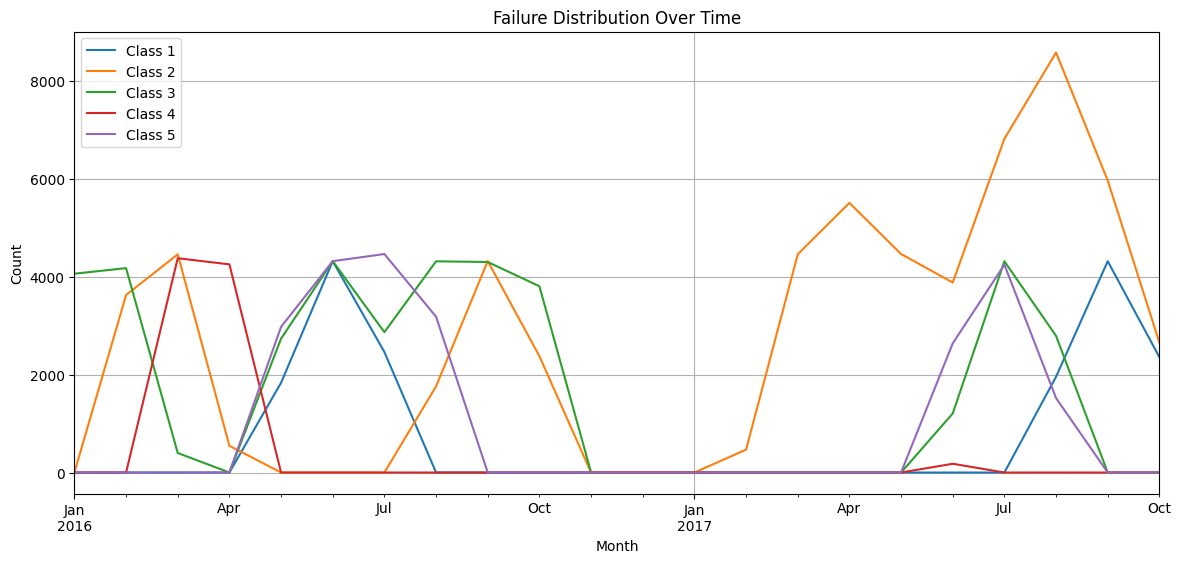



Last 60 days distribution:
Label
0    19665
1     6533
2     8333
Name: count, dtype: int64


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming your dataframe is 'df' with columns: 'Timestamp', 'Turbine_ID', 'Target'
# # Convert Timestamp to datetime if not already
# scada_60_2MDroped['Timestamp'] = pd.to_datetime(scada_60['Timestamp'])

# # 1. Overall failure counts
# print("Overall class distribution:")
# print(scada_60_2MDroped['Label'].value_counts().sort_index())
# print("\nPercentage:")
# print(scada_60_2MDroped['Label'].value_counts(normalize=True).sort_index() * 100)

# # 2. Failure distribution by turbine
# print("\n\nFailure distribution by turbine:")
# print(pd.crosstab(scada_60_2MDroped['Turbine_ID'], scada_60_2MDroped['Label']))

# # 3. Failure distribution -0over time (monthly
# scada_60_2MDroped['YearMonth'] = scada_60_2MDroped['Timestamp'].dt.to_period('M')
# monthly_failures = scada_60_2MDroped.groupby(['YearMonth', 'Label']).size().unstack(fill_value=0)
# print("\n\nMonthly failure distribution:")
# print(monthly_failures)

# # 4. Visual check - plot failures over time
# plt.figure(figsize=(14, 6))
# for failure_class in range(1, 6):
#     monthly_failures[failure_class].plot(label=f'Class {failure_class}')
# plt.xlabel('Month')
# plt.ylabel('Count')
# plt.title('Failure Distribution Over Time')
# plt.legend()
# plt.grid(True)
# plt.savefig(os.path.join(visualisations_path, 'failure_distri_over_time.png'))
# plt.show()

# # 5. Check last 60 days
# last_60_days = scada_60_2MDroped[scada_60_2MDroped['Timestamp'] >= scada_60_2MDroped['Timestamp'].max() - pd.Timedelta(days=60)]
# print("\n\nLast 60 days distribution:")
# print(last_60_days['Label'].value_counts().sort_index())

## time serie windowing

In [ ]:
# Separate features and target
X_train = scada_60_train.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_train = scada_60_train['Label']

# Data standarisation using StandardScaler:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Store feature names for later use
feature_names = X_train.columns

In [ ]:
# Separate features and target
X_test = scada_60_test.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_test = scada_60_test['Label']

# Data standarisation using StandardScaler:
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Separate features and target
X_val= scada_60_val.drop(['Label', 'Timestamp', 'Turbine_ID'], axis=1)
y_val = scada_60_val['Label']

# Data standarisation using StandardScaler:
X_val_scaled = scaler.transform(X_val)

In [ ]:
def create_windows(data, turbine_ids, labels, window_size=144, stride=24):
    """
    Create windowed data from time series.
    Window size of 144 represents 24 hours (6 samples per hour * 24 hours)
    Stride of 24 represents 4 hours (6 samples per hour * 4 hours)
    """
    X_windows = []
    y_windows = []
    turbine_id_windows = []

    # For each turbine
    for turbine_id in np.unique(turbine_ids):
        turbine_mask = turbine_ids == turbine_id
        turbine_data = data[turbine_mask]
        turbine_labels = labels[turbine_mask]

        # Create windows for this turbine
        for i in range(0, len(turbine_data) - window_size + 1, stride):
            X_windows.append(turbine_data[i:i+window_size])
            # Label the window by the last value's label
            # For predictive maintenance, we want to predict failures ahead of time
            y_windows.append(turbine_labels[i+window_size-1])
            turbine_id_windows.append(turbine_id)

    return np.array(X_windows), np.array(y_windows), np.array(turbine_id_windows)

# Get turbine IDs for each split
turbine_ids_train = scada_60_train['Turbine_ID'].values
turbine_ids_val = scada_60_val['Turbine_ID'].values
turbine_ids_test = scada_60_test['Turbine_ID'].values

# Create windows for each split
window_size = 144  # 24 hours of data
stride = 4     # 4 hours stride

X_train_windowed, y_train_windowed, _ = create_windows(X_train_scaled, turbine_ids_train, y_train.values,
                                                            window_size=window_size,
                                                            stride=stride)
X_val_windowed, y_val_windowed, _ = create_windows(X_val_scaled, turbine_ids_val, y_val.values,
                                                          window_size=window_size,
                                                          stride=stride)
X_test_windowed, y_test_windowed, _ = create_windows(X_test_scaled, turbine_ids_test, y_test.values,
                                                            window_size=window_size,
                                                            stride=stride)

print(f"Train windowed data shape: {X_train_windowed.shape}")
print(f"Train windowed labels shape: {y_train_windowed.shape}")
print(f"Validation windowed data shape: {X_val_windowed.shape}")
print(f"Validation windowed labels shape: {y_val_windowed.shape}")
print(f"Test windowed data shape: {X_test_windowed.shape}")
print(f"Test windowed labels shape: {y_test_windowed.shape}")

Train windowed data shape: (73554, 144, 26)
Train windowed labels shape: (73554,)
Validation windowed data shape: (8463, 144, 26)
Validation windowed labels shape: (8463,)
Test windowed data shape: (13079, 144, 26)
Test windowed labels shape: (13079,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# The data is already split into train, val, and test and windowed in the previous step.
# Rename variables for clarity and consistency with model training expectations.

X_train = X_train_windowed
y_train = y_train_windowed
X_val = X_val_windowed
y_val = y_val_windowed
X_test = X_test_windowed
y_test = y_test_windowed

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (73554, 144, 26)
Validation set shape: (8463, 144, 26)
Test set shape: (13079, 144, 26)


In [ ]:
unique, counts = np.unique(y_train_windowed, return_counts=True)
print("Class distribution (Training Data):", dict(zip(unique, counts)))

# 1. Compute class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=unique, y=y_train_windowed)
# class_weights = np.sqrt(class_weights)
class_weight_dict = dict(zip(unique, class_weights))
print("Class weights (Training Data):", class_weight_dict)

Class distribution (Training Data): {np.int64(0): np.int64(49461), np.int64(1): np.int64(2223), np.int64(2): np.int64(8068), np.int64(3): np.int64(10056), np.int64(4): np.int64(3746)}
Class weights (Training Data): {np.int64(0): np.float64(0.2974222114393158), np.int64(1): np.float64(6.617543859649123), np.int64(2): np.float64(1.8233515121467525), np.int64(3): np.float64(1.4628878281622912), np.int64(4): np.float64(3.9270688734650294)}


In [ ]:
# One-hot encode the labels
# Determine the total number of unique classes from the original data
num_classes_overall = len(np.unique(y_train)) # Get unique classes from the original full dataset
print(f"Total number of classes in the dataset: {num_classes_overall}")

# Use the total number of classes for one-hot encoding all splits
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes_overall)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes_overall)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes_overall)


# Create TF datasets
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test_onehot)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Total number of classes in the dataset: 5


Model architecture

In [ ]:
def build_model(input_shape, num_classes=6):
    inputs = tf.keras.Input(shape=input_shape)

    # CNN layers for spatial feature extraction
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Second CNN block
    x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # LSTM layers for temporal dynamics
    x = tf.keras.layers.LSTM(128, return_sequences=True)(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.LSTM(64, return_sequences=False)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Dense layers for classification
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Output layer
    outputs = tf.keras.layers.Dense(num_classes_overall, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model within strategy scope
model = build_model(input_shape=(X_train.shape[1], X_train.shape[2]),num_classes=num_classes_overall)

# Use CategoricalCrossentropy for multi-class classification
categorical_crossentropy_loss = tf.keras.losses.CategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=categorical_crossentropy_loss,
    metrics=['accuracy',
              tf.keras.metrics.Precision(),
              tf.keras.metrics.Recall(),
              tf.keras.metrics.AUC()]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 144, 26)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 144, 64)        │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 144, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 144, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 144, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 72, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 72, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 72, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 72, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 36, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 36, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,173 (1.64 MB)

 Trainable params: 429,893 (1.64 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(models_path,'model_Knw_Selected_scada_60_Post_failure_5Classes_Strid_4_smplMdl_NoFocalLoss_2M.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
    # class_weight=class_weight_dict  # Apply class weights
)

Epoch 1/50
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.5539 - auc: 0.7832 - loss: 1.2920 - precision: 0.6440 - recall: 0.3815 - val_accuracy: 0.3135 - val_auc: 0.6840 - val_loss: 1.6732 - val_precision: 0.3135 - val_recall: 0.3135 - learning_rate: 0.0010
Epoch 2/50
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.7353 - auc: 0.8569 - loss: 1.0138 - precision: 0.7595 - recall: 0.6616 - val_accuracy: 0.3135 - val_auc: 0.6831 - val_loss: 1.6950 - val_precision: 0.3135 - val_recall: 0.3135 - learning_rate: 0.0010
Epoch 3/50
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7389 - auc: 0.8556 - loss: 1.0026 - precision: 0.7541 - recall: 0.6743 - val_accuracy: 0.3117 - val_auc: 0.6783 - val_loss: 1.7430 - val_precision: 0.3116 - val_recall: 0.3116 - learning_rate: 0.0010
Epoch 4/50
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.7345 - auc: 0.8589 - loss: 0.9908 - precision: 0.7506 - recall: 0.6832 - val_accuracy: 0.3135 - val_auc: 0.6800 - val_lo

205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4881 - auc: 0.6723 - loss: 1.7714 - precision: 0.4881 - recall: 0.4881
Test loss: 1.5980608463287354
Test accuracy: 0.42174479365348816
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.42      1.00      0.59      5516
           1       0.00      0.00      0.00      2172
           2       0.00      0.00      0.00      4248
           3       0.00      0.00      0.00       663
           4       0.00      0.00      0.00       480

    accuracy                           0.42     13079
   macro avg       0.08      0.20      0.12     13079
weighted avg       0.18      0.42      0.25     13079



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


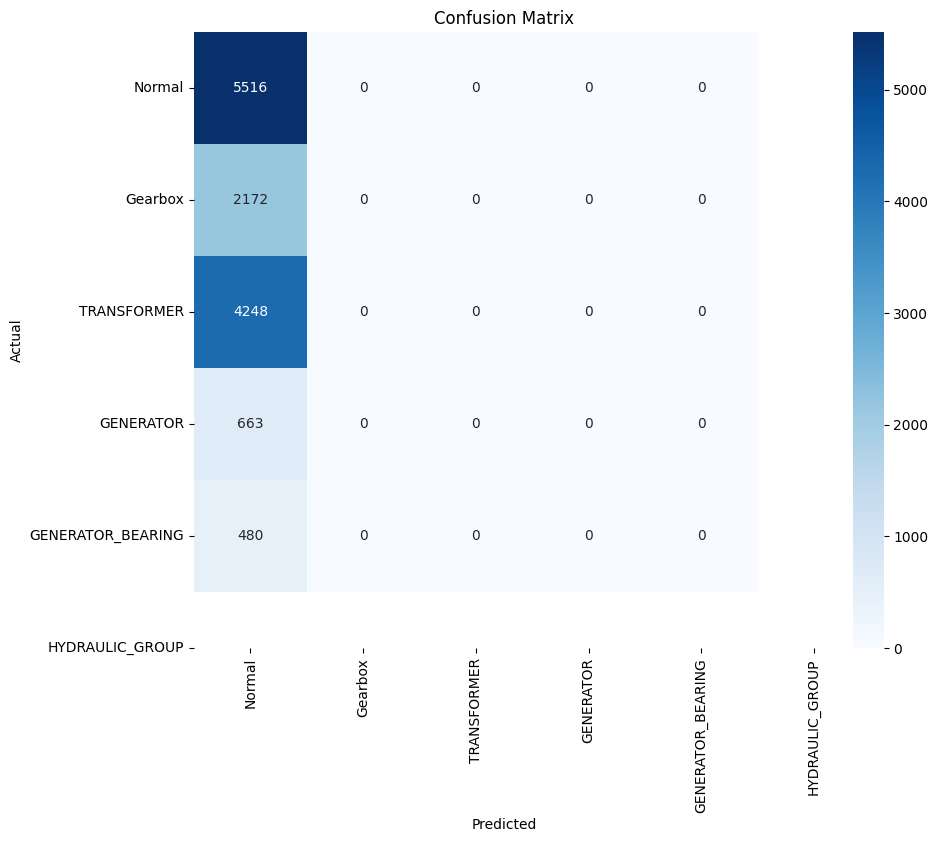

IndexError: index 5 is out of bounds for axis 1 with size 5

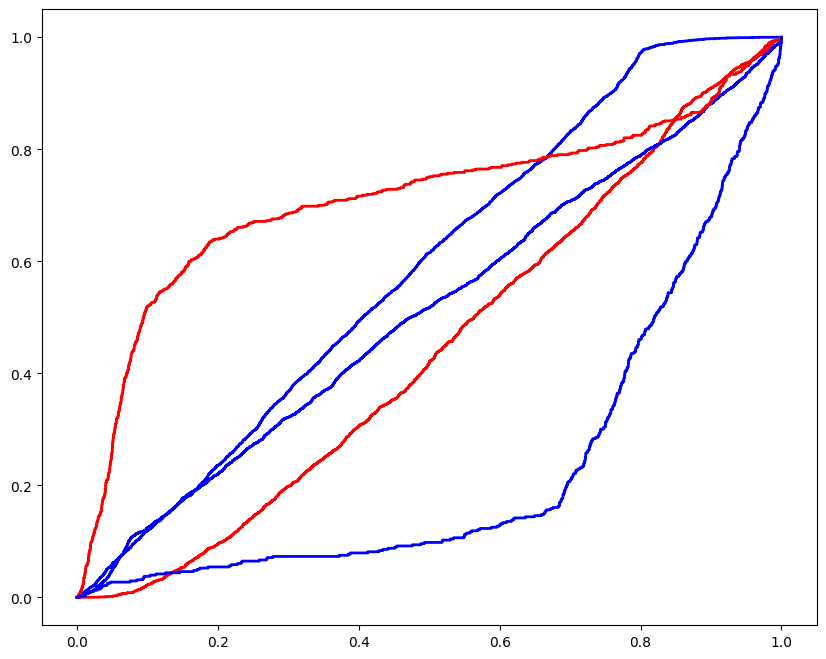

In [ ]:
import seaborn as sns
# Evaluate on test set
model_metrics_path = '/content/drive/MyDrive/School projects/PFE Project/Datasets/artical_level_data_preparation/visualizations/Model Matrics'
test_results = model.evaluate(test_dataset)
print(f"Test loss: {test_results[0]}")
print(f"Test accuracy: {test_results[1]}")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','GENERATOR_BEARING','HYDRAULIC_GROUP'],
            yticklabels=['Normal', 'Gearbox','TRANSFORMER','GENERATOR','GENERATOR_BEARING','HYDRAULIC_GROUP'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(model_metrics_path + "/CM_model_Kwd_Selected_scada_Postfailure_60_5Classes_CmplxMdl_stride_4_2Mout.png")
plt.show()

# ROC curves
from sklearn.metrics import roc_curve, auc
from itertools import cycle

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red'])
for i, color in zip(range(6), colors):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.savefig(model_metrics_path + "/RocCurve_model_Kwd_Selected_scada_postfailure_60_5Classes_CmplxMdl_stride_4_2Mout.png")
plt.show()

# Learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(model_metrics_path + "/Acc_Loss_model_Kwd_Selected_scada_postfailure_60_5Classes_CmplxMdl_stride_4_2Mout.png")
plt.show()


## CV

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.utils import to_categorical
# from sklearn.metrics import classification_report, confusion_matrix
# import numpy as np

# # Parameters
# sequence_length = 50  # Reasonable for 300k samples
# n_features = len([col for col in df.columns if col not in ['Timestamp', 'Turbine_ID', 'Label', 'YearMonth']])
# n_classes = 6
# batch_size = 256
# epochs = 20

# # Prepare data
# df_sorted = df.sort_values(['Turbine_ID','Timestamp']).reset_index(drop=True)
# X = df_sorted.drop(['Timestamp', 'Turbine_ID', 'Label', 'YearMonth'], axis=1).values
# y = df_sorted['Label'].values

# # Create sequences
# def create_sequences(X, y, seq_length):
#     Xs, ys = [], []
#     for i in range(len(X) - seq_length):
#         Xs.append(X[i:i+seq_length])
#         ys.append(y[i+seq_length])
#     return np.array(Xs), np.array(ys)

# X_seq, y_seq = create_sequences(X, y, sequence_length)
# y_cat = to_categorical(y_seq, n_classes)

# # Calculate class weights
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_seq), y=y_seq)
# class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# # Time Series Cross Validation
# tscv = TimeSeriesSplit(n_splits=4)
# fold = 1

# for train_idx, val_idx in tscv.split(X_seq):
#     print(f"\n{'='*50}")
#     print(f"Fold {fold}")
#     print(f"{'='*50}")

#     X_train, X_val = X_seq[train_idx], X_seq[val_idx]
#     y_train, y_val = y_cat[train_idx], y_cat[val_idx]

#     # Check class distribution
#     print(f"Train classes: {np.unique(np.argmax(y_train, axis=1), return_counts=True)}")
#     print(f"Val classes: {np.unique(np.argmax(y_val, axis=1), return_counts=True)}")

#     # Build model
#     model = Sequential([
#         LSTM(64, input_shape=(sequence_length, n_features), return_sequences=True),
#         Dropout(0.3),
#         LSTM(32),
#         Dropout(0.3),
#         Dense(n_classes, activation='softmax')
#     ])

#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#     # Train
#     history = model.fit(X_train, y_train,
#                        validation_data=(X_val, y_val),
#                        epochs=epochs,
#                        batch_size=batch_size,
#                        class_weight=class_weight_dict,
#                        verbose=1)

#     # Evaluate
#     y_pred = np.argmax(model.predict(X_val, batch_size=batch_size), axis=1)
#     y_true = np.argmax(y_val, axis=1)

#     print(f"\nFold {fold} Results:")
#     print(classification_report(y_true, y_pred))
#     print("\nConfusion Matrix:")
#     print(confusion_matrix(y_true, y_pred))

#     fold += 1

# print("\nTime Series CV Complete")

# Coding test

In [ ]:
def func(n):
    if n == 0:
        return 1
    return n * func(n-1)

print(func(3))